# `evap_cool` — example usage

Semiclassical evaporative cooling for ideal quantum and classical gases, following

> Arvizu-Velázquez et al., *Semi-classical evaporative cooling: classical and quantum distributions* (arXiv, 2026).

This notebook walks the same end-to-end pipeline through three traps — **box**, **quadrupole**, and **harmonic oscillator** — using a single helper, `run_trap_session`. For each trap we run all three statistics:

- **Maxwell–Boltzmann** as a high-temperature classical reference;
- **Bose–Einstein** through `run_with_bec_zoom`, which auto-zooms onto the BEC cliff if the standard loop halts;
- **Fermi–Dirac** through `run_with_fermi_zoom`, which auto-zooms through the `mpc` degeneracy halt that ends the standard loop once $\alpha = \mu/(k_B T)$ drifts past 0.

Both zooms share the same two-stage dynamic: a coarse pass locates the halt, a fine pass re-seeds a few steps earlier with higher mpmath precision and a finer Q-schedule. The helper exposes two toggles:

- `zoom={True, False}` — when `False`, both bosons and fermions run a single pass via `run_quantum_evaporation` with the coarse-stage parameters. Useful for sanity checks and quick iteration.
- `save={True, False}` — when `False`, results are returned in memory but no JSON is written. Useful for ephemeral experimentation.

When `save=True`, every saved JSON additionally carries the final committed `(N, T, μ, E)` under `metadata.N_last`, `metadata.T_last`, `metadata.Mu_last`, `metadata.E_last` (Maxwell–Boltzmann runs get only `N_last` / `T_last`), so downstream code can read the endpoint state without scanning the full results arrays.


## Setup

Make sure the package is importable. From the repo root:

```bash
pip install -e .
```

The simulations rely on `mpmath` for the polylog inner loop. The zoom wrapper temporarily raises `mp.mp.dps` for the fine stage and restores it on exit.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

from evap_cool import (
    # constants & traps
    ConstantsSI, ConstantsEV,
    BoxTrap, QuadrupoleTrap, OscillatorTrap,
    # initial-state and run helpers
    create_result_dict, create_mb_result_dict,
    build_cutoff_schedule,
    initialize_quantum_state, initialize_mb_state,
    run_quantum_evaporation, run_mb_evaporation,
    # Two-stage zoom wrappers
    run_with_bec_zoom, run_with_fermi_zoom, ZoomOutcome,
    # I/O — session folders prevent overwrites across re-runs
    make_session_dir, save_run, load_run, list_runs, list_sessions,
    # post-processing thermodynamics
    process_and_save_run, load_thermodynamics,
    # plots
    plot_combined_overview,
)

# One timestamped folder per notebook execution, e.g. runs/2026-05-06/14h32m17s/
# Every save_run / process_and_save_run call below writes inside this folder.
session = make_session_dir(base="runs")
print(f"Session folder: {session}")

mp.dps = 80


Session folder: runs\2026-05-22\13h23m52s


## The unified pipeline

For every trap we execute the same five steps:

1. **Solve the initial state.** Given $(N_0, T_0)$ and the trap geometry, solve for $\mu_0$ via the equilibrium relation $N_0 = \mathrm{prefactor}(T_0)\,g_s(\alpha_0)$, then evaluate $E_0$ and $\Omega_0$ at that $(T_0, \mu_0)$. Done separately for bosons and fermions.
2. **Build the coarse Q-schedule** with `build_cutoff_schedule`.
3. **Run the three statistics.** With `zoom=True`: bosons via `run_with_bec_zoom`, fermions via `run_with_fermi_zoom`, MB via `run_mb_evaporation`. With `zoom=False`: both quantum branches collapse to a single `run_quantum_evaporation` pass.
4. **Plot** the $T$ vs $Q$, $N$ vs $Q$, and $N$ vs $T$ overlays via `plot_combined_overview`.
5. **Save** all three to JSON in the session folder (only when `save=True`). The boson and fermion files carry the merged trajectory plus the per-stage `ZoomOutcome` in `metadata.zoom`; every file additionally records `N_last` / `T_last` / `Mu_last` / `E_last`.

The helper below packages exactly that. Each trap section then becomes a parameter dict plus one call.


In [2]:
def solve_initial_quantum_state(trap, N0, T0, sign, **kw):
    """Return (mu0, E0, Omega0) consistent with (N0, T0) for the given statistics."""
    alpha0 = trap.solve_alpha0(N0, T0, sign=sign, **kw)
    mu0    = alpha0 * trap.kB * T0
    E0     = float(trap.equilibrium_E(T0, mu0, sign).real)
    Omega0 = float(trap.equilibrium_Omega(T0, mu0, sign).real)
    return mu0, E0, Omega0


def run_trap_session(
    trap, name, *,
    N0, T0,
    Q0, dQ_coarse, n_steps_coarse,
    dQ_fine, n_steps_fine,
    session=None,
    alpha_floor_coarse=-1e-3,
    alpha_floor_fine=-1e-12,
    dps_fine=60,
    backoff=5,
    dT=1e-20, dmu=1e-30,
    show_plot=True,
    zoom=True,
    save=False,
):
    """Run B / F / MB on `trap` and (optionally) persist all three to `session`.

    Parameters
    ----------
    zoom : bool
        If True (default), bosons run through `run_with_bec_zoom` and
        fermions through `run_with_fermi_zoom`. Both wrappers do a
        coarse pass and, if it halts, a fine pass re-seeded `backoff`
        steps earlier with higher mpmath precision (`dps_fine`) and a
        finer Q-schedule (`dQ_fine`, `n_steps_fine`). The boson fine
        pass tightens `alpha_floor` toward 0; the fermion fine pass
        flips `real_part_on_mpc` on so the iteration can keep going
        once polylog crosses the z = -1 branch.

        If False, both bosons and fermions run a single pass via
        `run_quantum_evaporation` with the coarse-stage parameters
        only. `dQ_fine`, `n_steps_fine`, `alpha_floor_fine`, `dps_fine`,
        and `backoff` are accepted but unused in that mode.
    save : bool
        If True, three JSON files are written to `session`
        (`<name>_bosons.json`, `<name>_fermions.json`, `<name>_mb.json`).
        If False (default), no files are written; the in-memory results
        are still returned. `session` is required only when `save=True`.
    """
    print(f"\n=== {name} =====================================================")

    if save and session is None:
        raise ValueError("`session` must be provided when save=True.")

    # 1. Initial states for the two quantum statistics.
    mu0_b, E0_b, Omega0_b = solve_initial_quantum_state(trap, N0, T0, sign=+1)
    mu0_f, E0_f, Omega0_f = solve_initial_quantum_state(
        trap, N0, T0, sign=-1, alpha_hi=20.0,
    )
    alpha0_b = mu0_b / (trap.kB * T0)
    alpha0_f = mu0_f / (trap.kB * T0)
    print(f"  alpha0 (bosons)   = {alpha0_b:+.4f}")
    print(f"  alpha0 (fermions) = {alpha0_f:+.4f}")

    # 2. Coarse Q-schedule (used by F, MB, and stage 1 of bosons when zooming).
    Q_schedule = build_cutoff_schedule(Q0=Q0, dQ=dQ_coarse, n_steps=n_steps_coarse)

    # 3a. Bosons.
    if zoom:
        res_b, zoom_b = run_with_bec_zoom(
            trap,
            N0=N0, T0=T0, mu0=mu0_b, E0=E0_b, Omega0=Omega0_b,
            Q0=Q0,
            dQ_coarse=dQ_coarse, n_steps_coarse=n_steps_coarse,
            dQ_fine=dQ_fine,     n_steps_fine=n_steps_fine,
            dT=dT, dmu=dmu, sign=+1,
            alpha_floor_coarse=alpha_floor_coarse,
            alpha_floor_fine=alpha_floor_fine,
            dps_fine=dps_fine,
            backoff=backoff,
            verbose=False,
        )
        out_b = zoom_b  # duck-types as RunOutcome
    else:
        res_b = create_result_dict()
        res_b["Q"] = list(Q_schedule)
        initialize_quantum_state(res_b, N0, T0, mu0_b, E0_b, Omega0_b)
        out_b = run_quantum_evaporation(
            res_b, trap, N0,
            n_steps=n_steps_coarse, dT=dT, dmu=dmu, sign=+1,
            alpha_floor=alpha_floor_coarse, verbose=False,
        )
        zoom_b = None

    # 3b. Fermions.
    if zoom:
        res_f, zoom_f = run_with_fermi_zoom(
            trap,
            N0=N0, T0=T0, mu0=mu0_f, E0=E0_f, Omega0=Omega0_f,
            Q0=Q0,
            dQ_coarse=dQ_coarse, n_steps_coarse=n_steps_coarse,
            dQ_fine=dQ_fine,     n_steps_fine=n_steps_fine,
            dT=dT, dmu=dmu, sign=-1,
            dps_fine=dps_fine,
            backoff=backoff,
            verbose=False,
        )
        out_f = zoom_f
    else:
        res_f = create_result_dict()
        res_f["Q"] = list(Q_schedule)
        initialize_quantum_state(res_f, N0, T0, mu0_f, E0_f, Omega0_f)
        out_f = run_quantum_evaporation(
            res_f, trap, N0,
            n_steps=n_steps_coarse, dT=dT, dmu=dmu, sign=-1,
            verbose=False,
        )
        zoom_f = None

    # 3c. Maxwell-Boltzmann reference.
    res_mb = create_mb_result_dict()
    res_mb["Q"] = list(Q_schedule)
    initialize_mb_state(res_mb, N0, T0)
    run_mb_evaporation(res_mb, trap, N0, n_steps=n_steps_coarse)

    # Summary lines — uniform regardless of zoom mode.
    def _summary(label, zoom_outcome, plain_outcome):
        if zoom_outcome is not None:
            fine_str = (f"+fine={zoom_outcome.fine.n_completed}"
                        if zoom_outcome.fine is not None else "+fine=skipped")
            print(f"  {label:9s} : coarse={zoom_outcome.coarse.n_completed} "
                  f"{fine_str}  total={zoom_outcome.n_total_committed}  "
                  f"halt={zoom_outcome.halt_reason}")
        else:
            print(f"  {label:9s} : {plain_outcome.n_completed}/{n_steps_coarse}  "
                  f"halt={plain_outcome.halt_reason}")

    _summary("bosons",   zoom_b, out_b)
    _summary("fermions", zoom_f, out_f)
    print(f"  MB        : {n_steps_coarse}/{n_steps_coarse}")

    # 4. Plot overlay.
    if show_plot:
        n_b = zoom_b.n_total_committed if zoom_b is not None else out_b.n_completed
        n_f = zoom_f.n_total_committed if zoom_f is not None else out_f.n_completed
        fig = plot_combined_overview(
            res_b, res_f, res_mb,
            trap_name=name,
            n_b=n_b,
            n_f=n_f,
        )
        plt.show()

    # 5. Save — all three JSONs into the session, identically named.
    if save:
        stem = name.lower()
        common = dict(
            N0=N0, T0=T0,
            Q0=Q0, dQ=dQ_coarse, n_steps=n_steps_coarse,
            dQ_fine=dQ_fine, n_steps_fine=n_steps_fine,
            alpha_floor_coarse=alpha_floor_coarse,
            alpha_floor_fine=alpha_floor_fine,
            dps_fine=dps_fine, backoff=backoff,
            zoom=zoom,
        )

        # Bosons: pass zoom metadata only when zoom actually ran.
        boson_extra = (
            {"zoom": zoom_b.to_metadata()} if zoom_b is not None else None
        )
        save_run(
            res_b, session / f"{stem}_bosons.json",
            trap=trap,
            parameters={**common,
                        "mu0": mu0_b, "E0": E0_b, "Omega0": Omega0_b, "sign": +1},
            outcome=out_b,
            extra_metadata=boson_extra,
        )

        # Fermions: same pattern, now that we have a fermion zoom.
        fermion_extra = (
            {"zoom": zoom_f.to_metadata()} if zoom_f is not None else None
        )
        save_run(
            res_f, session / f"{stem}_fermions.json",
            trap=trap,
            parameters={**common,
                        "mu0": mu0_f, "E0": E0_f, "Omega0": Omega0_f, "sign": -1},
            outcome=out_f,
            extra_metadata=fermion_extra,
        )

        save_run(
            res_mb, session / f"{stem}_mb.json",
            trap=trap,
            parameters={**common, "sign": 0},
            outcome=None,  # MB loop has no early-halt machinery
        )

    return {
        "bosons":   (res_b,  out_b),
        "fermions": (res_f,  out_f),
        "mb":       (res_mb, None),
    }


## 1. Box trap

3D hard-walled cavity, density of states $g(\epsilon) \propto \epsilon^{1/2}$, so $s = 3/2$. The cleanest case for observing the BEC cliff in the bosons run.



=== Box =====================================================
  alpha0 (bosons)   = -8.8990
  alpha0 (fermions) = -8.8989
  bosons    : coarse=9994 +fine=33  total=10022  halt=ValueError: mu = 3.631336315443867e-32 >= 0 (crossed BEC boundary or NaN)
  fermions  : coarse=9992 +fine=1000  total=10987  halt=None
  MB        : 9999/9999


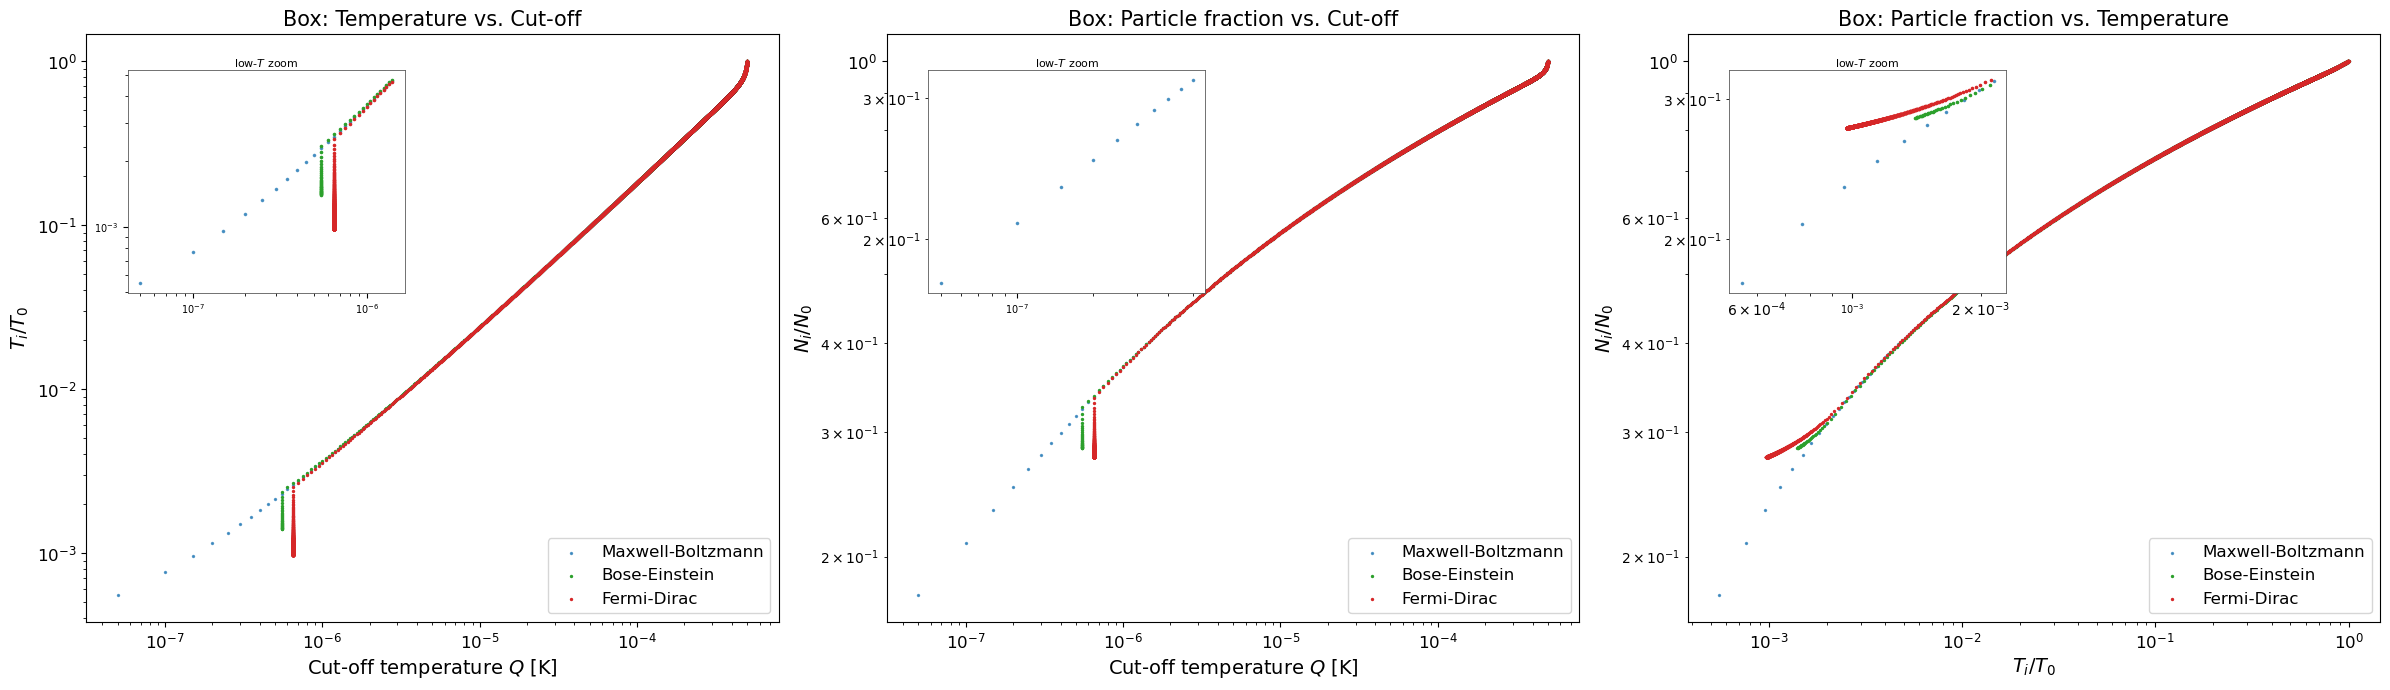

In [3]:
results_box = run_trap_session(
    BoxTrap(V=1e-11), name="Box",
    N0=1.0e7, T0=5.0e-5,
    Q0=5e-4, dQ_coarse=5e-8,  n_steps_coarse=9999,
    dQ_fine=1e-50,            n_steps_fine=1000,
    session=session,
    zoom=True, save=True,
)

## 2. Quadrupole trap

Linear potential $U(r) = \bar A\, r$, density of states $g(\epsilon) \propto \epsilon^{7/2}$, so $s = 9/2$. Same call signature, different trap.



=== Quadrupole =====================================================
  alpha0 (bosons)   = -18.3633
  alpha0 (fermions) = -18.3633
  bosons    : coarse=9950 +fine=skipped  total=9950  halt=None
  fermions  : coarse=9947 +fine=1000  total=10942  halt=None
  MB        : 9950/9950


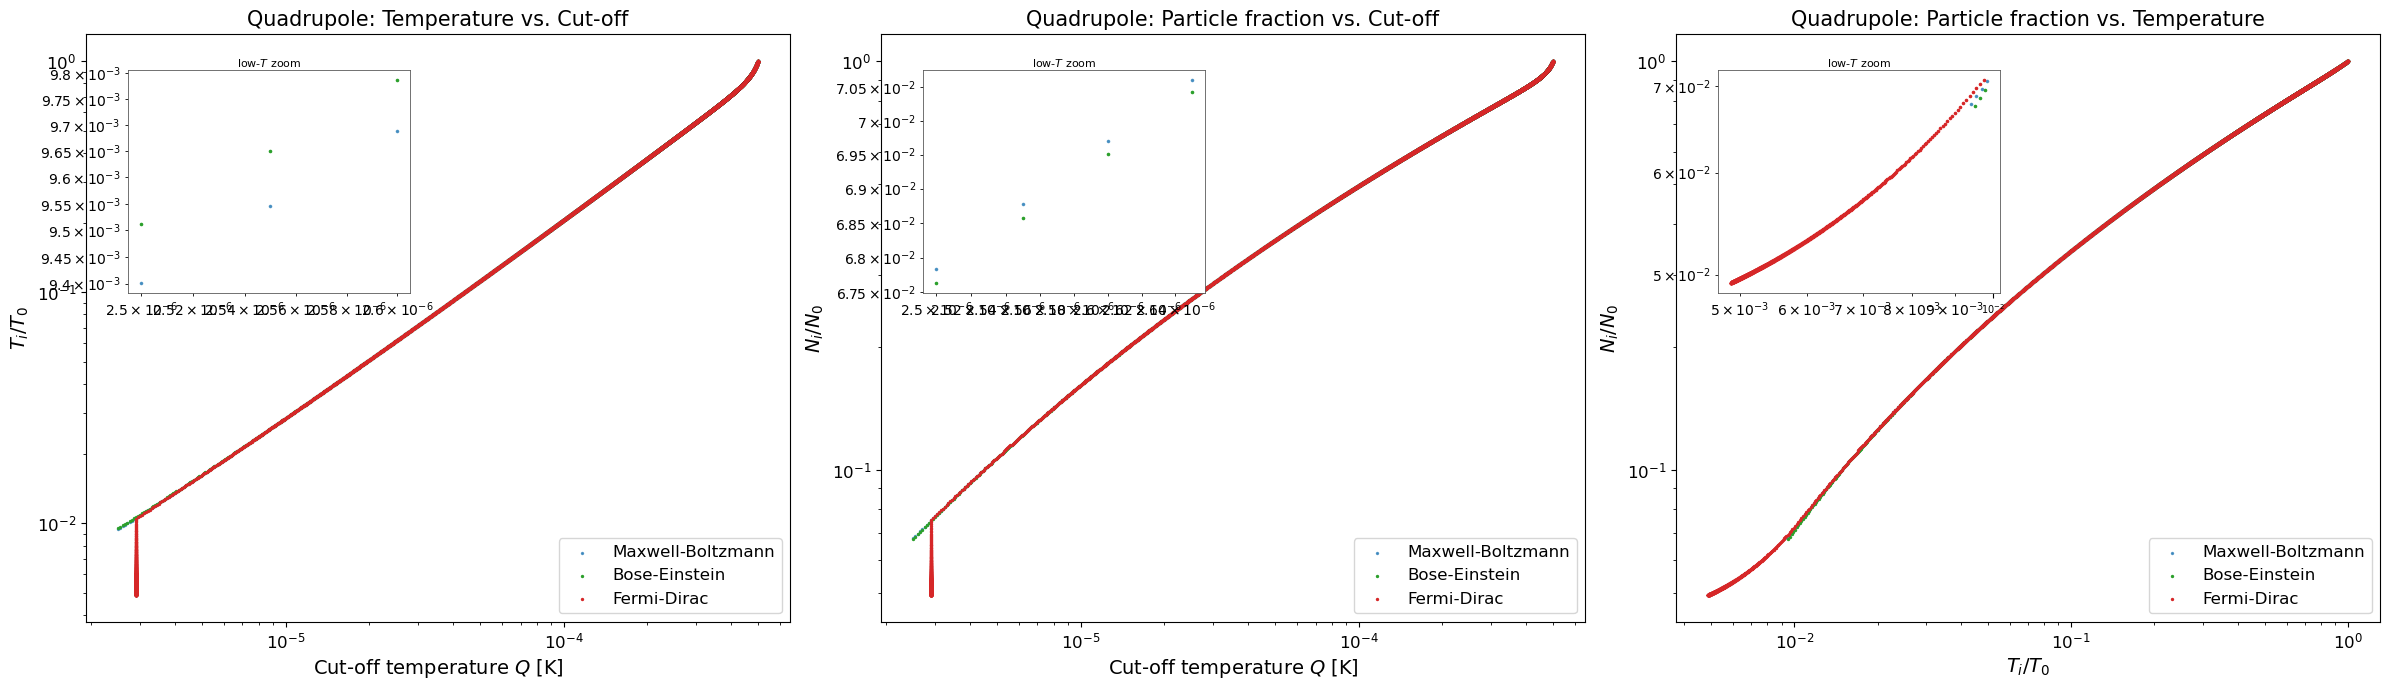

In [4]:
results_quad = run_trap_session(
    QuadrupoleTrap(A_bar=1e-15), name="Quadrupole",
    N0=1.0e7, T0=5.0e-5,
    Q0=5e-4, dQ_coarse=5e-8,  n_steps_coarse=9950,
    dQ_fine=5e-50,            n_steps_fine=1000,
    session=session,
    zoom=True, save=True,
)

## 3. Harmonic oscillator trap

Isotropic 3D oscillator $U(r) = \tfrac12 m\omega^2 r^2$, density of states $g(\epsilon) \propto \epsilon^2$, so $s = 3$.



=== Oscillator =====================================================
  alpha0 (bosons)   = -11.6359
  alpha0 (fermions) = -11.6359
  bosons    : coarse=9931 +fine=6  total=9932  halt=ValueError: mu = 3.0970898748232247e-13 >= 0 (crossed BEC boundary or NaN)
  fermions  : coarse=9983 +fine=47  total=10025  halt=ValueError: non-positive or NaN T = -5.208236063955839e-08
  MB        : 9999/9999


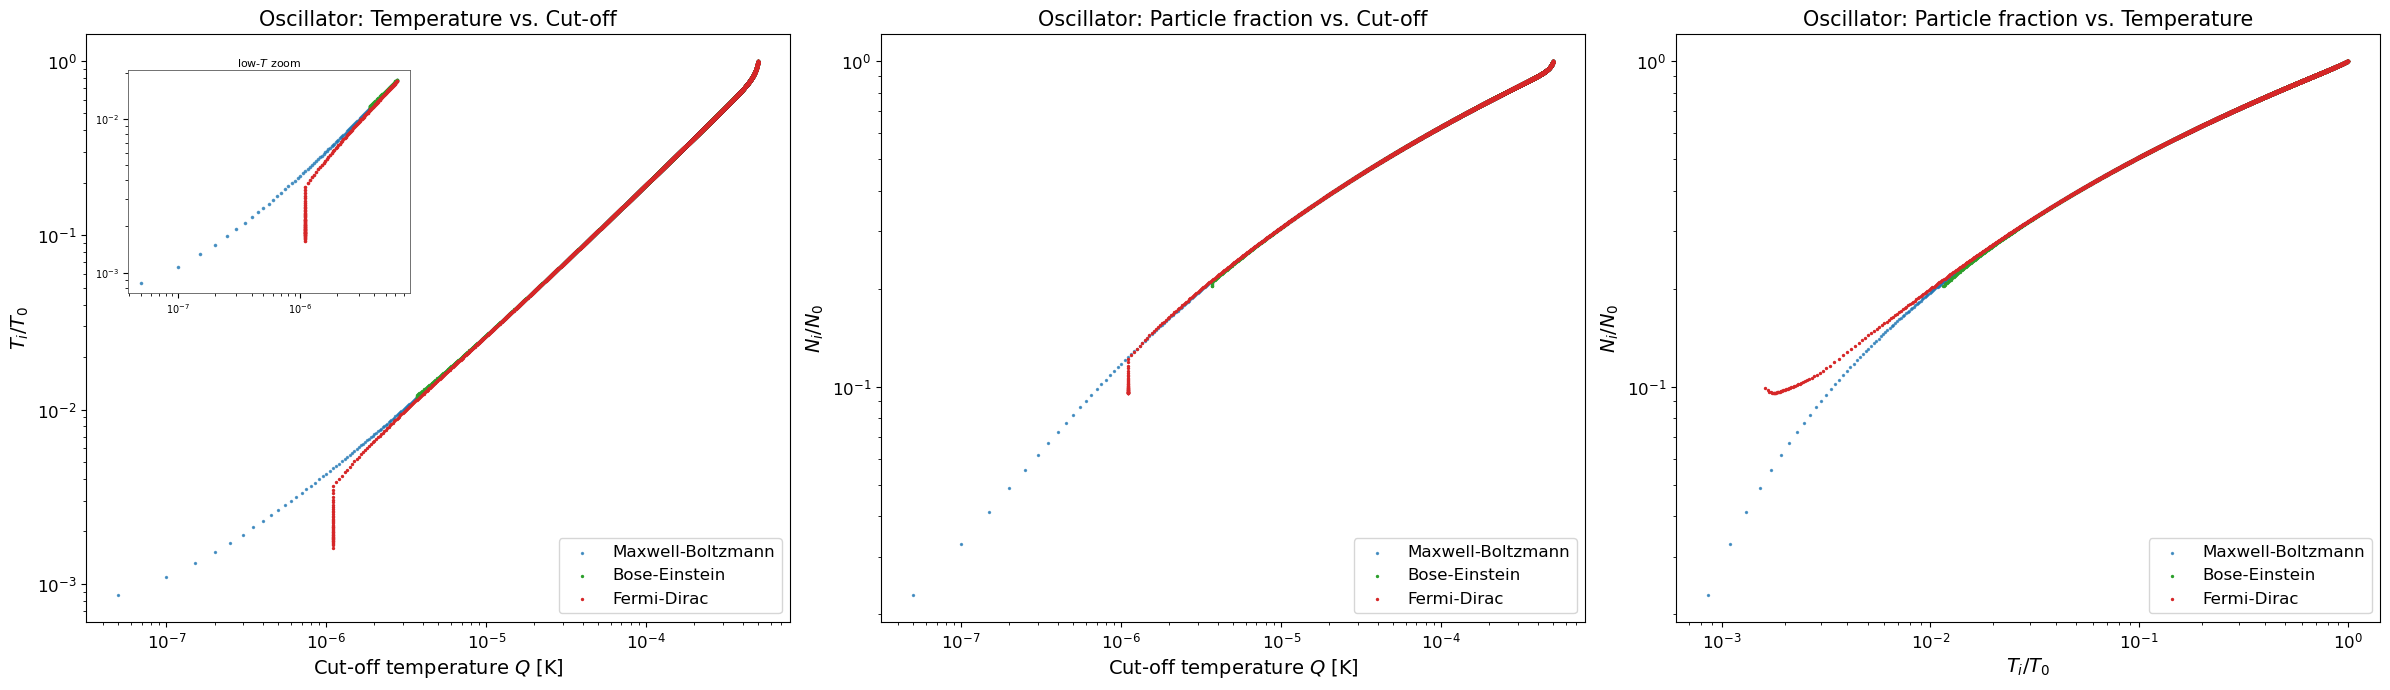

In [5]:
results_osc = run_trap_session(
    OscillatorTrap(omega=2 * np.pi * 100), name="Oscillator",
    N0=1.0e7, T0=5.0e-5,
    Q0=5e-4, dQ_coarse=5e-8,  n_steps_coarse=9999,
    dQ_fine=5e-50,            n_steps_fine=1000,
    session=session,
    zoom=True, save=True,
)

## 4. Quick experimentation mode (`zoom=False`, `save=False`)

The two new toggles are independent. When iterating on parameters, set both to `False`: each statistics branch then runs a single, lower-precision `run_quantum_evaporation` pass, no JSON is written, and `session` becomes optional. Returned results are still the in-memory dicts, so you can inspect the trajectories or pass them to the plotting helpers.

This is useful for finding the right coarse `dQ` and `n_steps` before committing to a full save+zoom run.



=== Box =====================================================
  alpha0 (bosons)   = -8.8990
  alpha0 (fermions) = -8.8989
  bosons    : coarse=9994 +fine=33  total=10022  halt=ValueError: mu = 3.631336315443867e-32 >= 0 (crossed BEC boundary or NaN)
  fermions  : coarse=9992 +fine=500  total=10487  halt=None
  MB        : 9999/9999


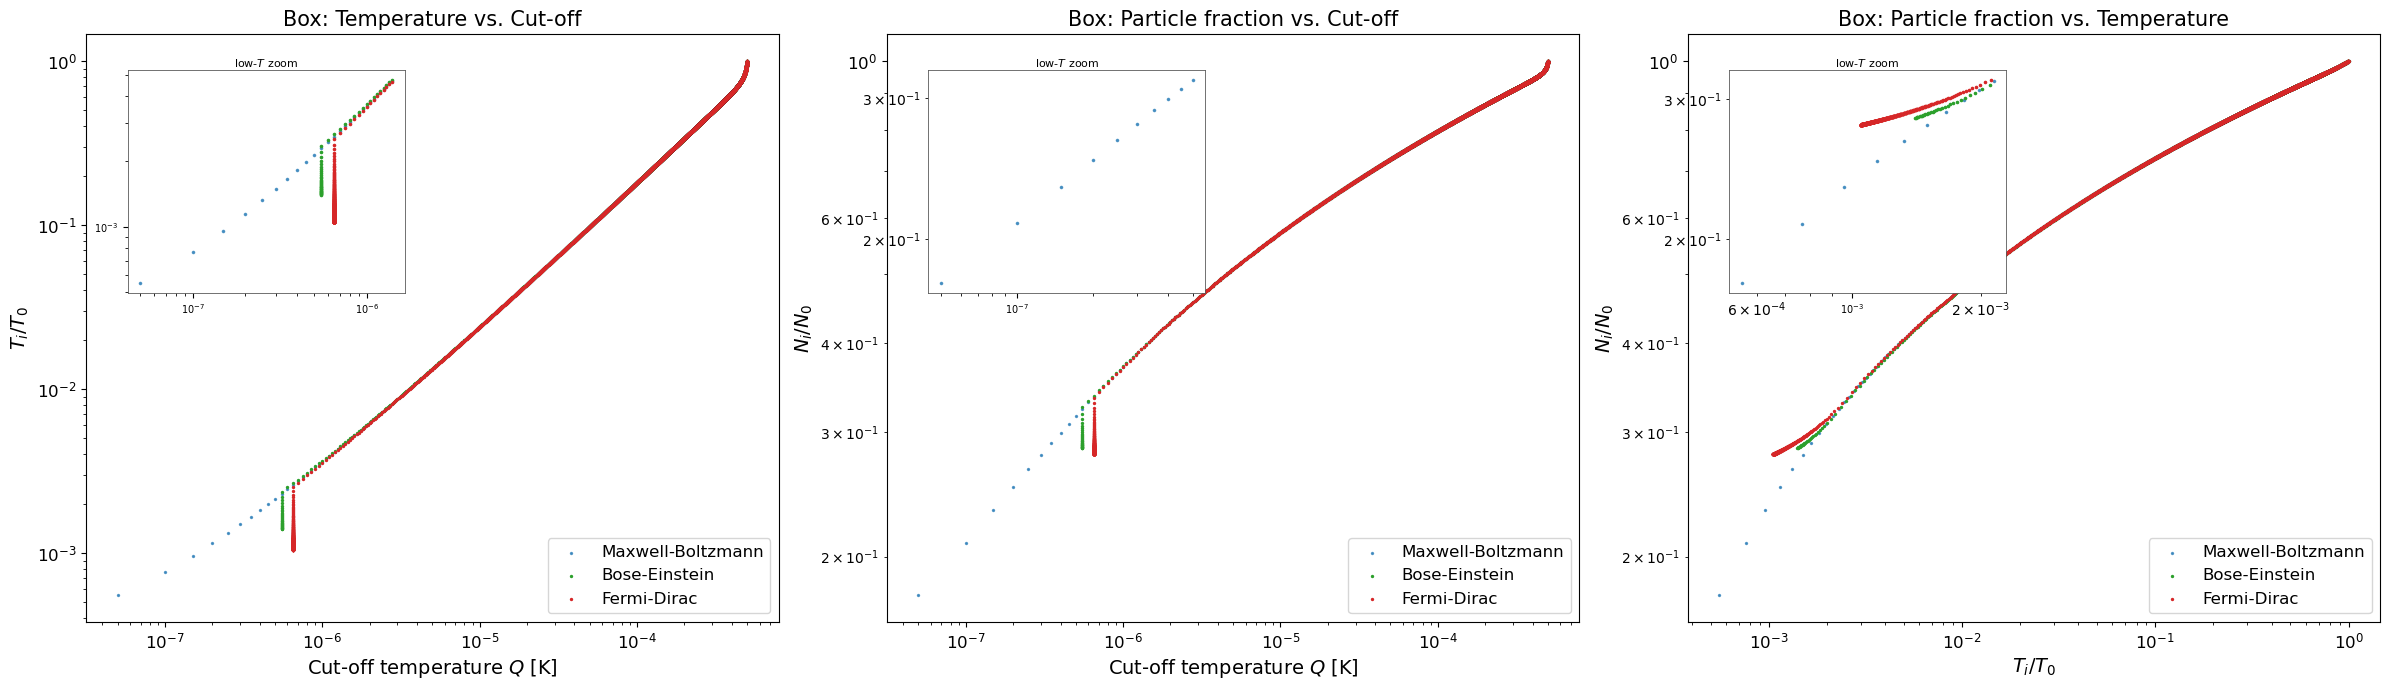

In-memory bosons   : 10023 states, last N = 2.8417e+06
In-memory fermions : 10488 states, last N = 2.7868e+06


In [6]:
# Same call as the box section, but ephemeral and single-pass.
# Note that `session` is unused when save=False.
#mp.dps=70
results_box_quick = run_trap_session(
    BoxTrap(V=1e-11), name="Box",
    N0=1.0e7, T0=5.0e-5,
    Q0=5e-4, dQ_coarse=5e-8,  n_steps_coarse=9999,
    dQ_fine=1e-40,            n_steps_fine=500,
    session=session,
    zoom=True, save=True,
)
# In-memory access; nothing written to disk.
res_b, out_b = results_box_quick["bosons"]
res_f, out_f = results_box_quick["fermions"]
print(f"In-memory bosons   : {len(res_b['N'])} states, last N = {res_b['N'][-1]:.4e}")
print(f"In-memory fermions : {len(res_f['N'])} states, last N = {res_f['N'][-1]:.4e}")

## 5. Loading runs back

`load_run` returns the full payload (`parameters`, `metadata`, `results`). Schema version is checked on load.

For runs written by `run_trap_session`:

- Bosons and fermions files carry per-stage zoom metadata under `metadata.zoom` (whenever `zoom=True`). Each `ZoomOutcome.to_metadata()` block has `coarse`, `fine` (or `None` if skipped), `seed_index`, and `n_total_committed`.
- Every file carries the final committed state under `metadata.N_last`, `metadata.T_last`, `metadata.Mu_last`, `metadata.E_last`. Maxwell–Boltzmann files carry only `N_last` and `T_last` (those are the only quantities the MB loop records).


In [11]:
print(f"Sessions on disk: {[s.name for s in list_sessions('runs')]}")
print(f"Runs in current session ({session.name}):\n")

for path in list_runs(session, include_thermo=False):
    payload = load_run(path)
    meta    = payload["metadata"]
    params  = payload["parameters"]
    outcome = meta.get("outcome", {}) or {}
    trap_md = meta.get("trap", {}) or {}
    zoom_md = meta.get("zoom")
    line = (f"  {path.name:32s}  trap={trap_md.get('name','?'):<11s}  "
            f"sign={params.get('sign', 0):>+2d}  "
            f"steps={outcome.get('n_completed','?')}/{outcome.get('n_steps_requested','?')}")
    if zoom_md is not None:
        c = zoom_md.get("coarse", {}) or {}
        f = zoom_md.get("fine")
        f_n = (f.get("n_completed") if isinstance(f, dict) else "skipped")
        line += f"   [zoom: coarse={c.get('n_completed','?')} fine={f_n}]"
    print(line)


Sessions on disk: ['00h51m34s', '12h23m46s', '12h35m57s', '14h28m43s', '15h39m09s', '18h51m55s', '19h15m07s', '12h13m21s', '10h56m34s', '11h34m11s', '11h04m10s', '11h13m19s', '11h37m21s', '11h39m30s', '11h46m42s', '13h23m52s']
Runs in current session (13h23m52s):

  box_bosons.json                   trap=box          sign=+1  steps=10022/10499   [zoom: coarse=9994 fine=33]
  box_fermions.json                 trap=box          sign=-1  steps=10487/10499   [zoom: coarse=9992 fine=500]
  box_mb.json                       trap=box          sign=+0  steps=?/?
  oscillator_bosons.json            trap=oscillator   sign=+1  steps=9932/10999   [zoom: coarse=9931 fine=6]
  oscillator_fermions.json          trap=oscillator   sign=-1  steps=10025/10999   [zoom: coarse=9983 fine=47]
  oscillator_mb.json                trap=oscillator   sign=+0  steps=?/?
  quadrupole_bosons.json            trap=quadrupole   sign=+1  steps=9950/9950   [zoom: coarse=9950 fine=skipped]
  quadrupole_fermions.json      

### 5.1 Final committed state at a glance

`N_last`, `T_last`, `Mu_last`, `E_last` are recorded in `metadata` at save time. They sit right next to `outcome.n_completed` and `outcome.halt_reason`, so a downstream consumer can answer "where did this run end up" without ever reading the time-series arrays.


In [12]:
for path in list_runs(session, include_thermo=False):
    meta = load_run(path)["metadata"]
    fields = []
    for key in ("N_last", "T_last", "Mu_last", "E_last"):
        if key in meta:
            fields.append(f"{key}={meta[key]:+.4e}")
        else:
            fields.append(f"{key}=--")
    print(f"  {path.name:32s}  " + "  ".join(fields))


  box_bosons.json                   N_last=+2.8417e+06  T_last=+6.9856e-08  Mu_last=-2.7461e-31  E_last=+3.5658e-24
  box_fermions.json                 N_last=+2.7868e+06  T_last=+5.2425e-08  Mu_last=+6.5263e-31  E_last=+3.6163e-24
  box_mb.json                       N_last=+1.2230e+06  T_last=+1.5714e-08  Mu_last=--  E_last=--
  oscillator_bosons.json            N_last=+2.0256e+06  T_last=+5.7247e-07  Mu_last=-2.5250e-13  E_last=+2.7030e-04
  oscillator_fermions.json          N_last=+1.0264e+06  T_last=+7.1387e-08  Mu_last=+7.4208e-11  E_last=+6.0803e-05
  oscillator_mb.json                N_last=+1.1256e+05  T_last=+3.0141e-08  Mu_last=--  E_last=--
  quadrupole_bosons.json            N_last=+6.6690e+05  T_last=+4.6868e-07  Mu_last=-4.1601e-12  E_last=+1.1825e-04
  quadrupole_fermions.json          N_last=+4.9289e+05  T_last=+2.4406e-07  Mu_last=+6.1511e-11  E_last=+5.3683e-05
  quadrupole_mb.json                N_last=+6.6899e+05  T_last=+4.6291e-07  Mu_last=--  E_last=--


## 6. Post-process equilibrium thermodynamics

Each rethermalised state $(T_i, \mu_i)$ saved during evaporation is a genuine equilibrium of the trap, so we can compute equilibrium thermodynamic quantities on each saved state and write them to a paired `*_thermo.json`.

The box case at $s = 3/2$ is now derived in `Caja_Ideal.pdf`, and its closed forms reduce algebraically to the generic pure-geometry implementation in `equilibrium.py`, so box runs are post-processed alongside the quadrupole and oscillator.

Maxwell–Boltzmann runs have no $\mu_i$ recorded, so they cannot be post-processed.


In [13]:
# Post-process the bosons + fermions runs for every paper-validated trap.
# Per-step thermodynamics are computed on every committed state, including
# states produced by the fine zoom stage.

trap_box  = BoxTrap(V=1e-11)
trap_quad = QuadrupoleTrap(A_bar=1e-15)
trap_osc  = OscillatorTrap(omega=2 * np.pi * 100)

# Box — equilibrium thermodynamics validated against Caja_Ideal.pdf.
process_and_save_run(session / "box_bosons.json",       trap_box,  sign=+1)
process_and_save_run(session / "box_fermions.json",     trap_box,  sign=-1)

# Quadrupole
process_and_save_run(session / "quadrupole_bosons.json",   trap_quad, sign=+1)
process_and_save_run(session / "quadrupole_fermions.json", trap_quad, sign=-1)

# Oscillator
process_and_save_run(session / "oscillator_bosons.json",   trap_osc, sign=+1)
process_and_save_run(session / "oscillator_fermions.json", trap_osc, sign=-1)

print("Thermo files in this session:")
for p in list_runs(session):
    if p.stem.endswith("_thermo"):
        print(f"  {p.relative_to(session)}")


KeyboardInterrupt: 

### 6.1 Inspect a thermo file

Each thermo file exposes the same per-step time series as the source run, indexed by step. For zoom-augmented bosons or fermions, the index runs over the merged trajectory (both stages stitched).


In [10]:
thermo = load_thermodynamics(session / "quadrupole_bosons_thermo.json")
results_thermo = thermo["results"]
src_meta       = thermo["metadata"]["source_run"]

print(f"Source run    : {src_meta['filename']}")
print(f"Source saved  : {src_meta['saved_at']}")
print(f"Trap          : {src_meta['trap']['name']}  (s = {src_meta['trap']['s']})")
print(f"N steps       : {len(results_thermo['S'])}")
print(f"S[0]          : {results_thermo['S'][0]:.3e}")
print(f"S[-1]         : {results_thermo['S'][-1]:.3e}")
print(f"kappa_T[0]    : {results_thermo['kappa_T'][0]:.3e}")
print(f"kappa_T[-1]   : {results_thermo['kappa_T'][-1]:.3e}")


Source run    : quadrupole_bosons.json
Source saved  : 2026-05-22T14:16:06
Trap          : quadrupole  (s = 4.5)
N steps       : 9951
S[0]          : 2.056e+04
S[-1]         : 3.143e+02
kappa_T[0]    : 2.321e+46
kappa_T[-1]   : 3.925e+49


## 7. Where to go from here

A few natural extensions worth flagging:

- **Tighter zoom.** `dQ_fine` and `dps_fine` control how far each zoom can push past its halt. For paper-quality plots of the BEC cliff or the fermion degeneracy edge, drop `dQ_fine` by another 2–3 orders of magnitude and bump `dps_fine` to 80–120. Both wrappers restore `mp.mp.dps` on exit, so it's safe to call them in a loop.
- **Adaptive Q-schedule.** The current schedule is linear by step. A geometric or log-spaced schedule would put more density near the halt for the *coarse* stage too — straightforward to add via a custom builder that returns a list, since `run_quantum_evaporation` only reads `results["Q"]`.
- **Multi-stage zoom.** `run_with_bec_zoom` and `run_with_fermi_zoom` are two-stage by design. For a third stage, re-invoke the wrapper on the merged dict's last good state (extracted via the same indexing convention used inside each helper).
- **Quick experimentation.** `zoom=False, save=False` gives a single fast pass with no disk writes — useful when tuning a coarse schedule before committing to a full save+zoom run. `session` can be left as `None` in this mode.
- **Sanity loop.** Comparing the merged boson trajectory against MB at high $T$ and against the analytic BEC critical $T_c$ at the cliff is a good integration test once `dps_fine` is tuned. The analogous fermion test compares against the Sommerfeld expansion at low $T/T_F$ for the rethermalised state past the mpc halt.
